<a href="https://colab.research.google.com/github/DinoKiller0607/My_Pytorch_Notes/blob/main/02_pytorch_classification.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Classification
Classification is a problem of predicting whether something is one thing or the other (there can be multiple things as the option, though).
Book version of the notebook – https://www.learnpytorch.io/02_pytorch_classification/

All other resources – https://github.com/DinoKiller0607/pytorch-deep-learning

In case you get stuck, refer – https://github.com/mrdbourke/pytorch-deep-learning/discussions

## Making classification data ready

In [1]:
from sklearn.datasets import make_circles
import numpy as np
# Make aa 1000 samples
n_samples = 1000
# Create circles
X, y = make_circles(n_samples,
                    noise = 0.03,
                    random_state = 42)
len(X), len(y)

(1000, 1000)

In [2]:
# Print the data
print(f"First 5 samples of X are :\n{X[:5]}")
print(f"First 5 samples of y are :\n{y[:5]}")

First 5 samples of X are :
[[ 0.75424625  0.23148074]
 [-0.75615888  0.15325888]
 [-0.81539193  0.17328203]
 [-0.39373073  0.69288277]
 [ 0.44220765 -0.89672343]]
First 5 samples of y are :
[1 1 1 1 0]


In [3]:
# Make a Dataframe of circle data
import pandas as pd
circles = pd.DataFrame({"X1": X[:, 0],
                        "X2": X[:, 1],
                        "label":y})
circles.head(10)

,X1,X2,label
0,0.754246,0.231481,1
1,-0.756159,0.153259,1
2,-0.815392,0.173282,1
3,-0.393731,0.692883,1
4,0.442208,-0.896723,0
5,-0.479646,0.676435,1
6,-0.013648,0.803349,1
7,0.771513,0.147760,1
8,-0.169322,-0.793456,1
9,-0.121486,1.021509,0


In [4]:
circles.label.value_counts()

,count
label,
1,500
0,500


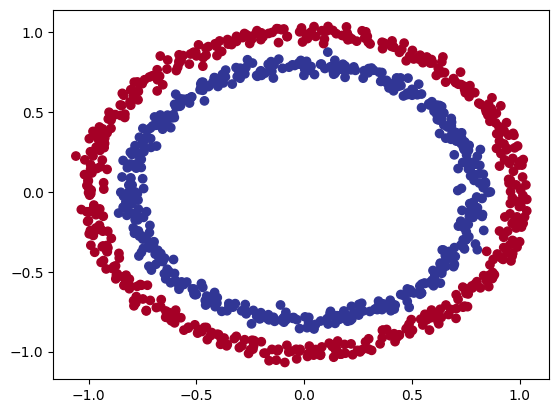

In [5]:
# Visualize, Visualize, Visualize
import matplotlib.pyplot as plt
plt.scatter(x=X[:, 0],
            y=X[:, 1],
            c=y,
            cmap=plt.cm.RdYlBu
            );

**Note:** The data we are working with is often referred to as a toy dataset, a dataset that is small enough to experiment but still sizeable enough to practice the fundamentals.

### Check input and output shapes

In [6]:
X.shape, y.shape

((1000, 2), (1000,))

In [7]:
X

array([[ 0.75424625,  0.23148074],
       [-0.75615888,  0.15325888],
       [-0.81539193,  0.17328203],
       ...,
       [-0.13690036, -0.81001183],
       [ 0.67036156, -0.76750154],
       [ 0.28105665,  0.96382443]])

In [8]:
# View the first example of features and labels
X_sample = X[0]
y_sample = y[0]
print(f"Values for one sample of X: {X_sample} and the same for y: {y_sample}")
print(f"Shapes for one sample of X: {X_sample.shape} and the same for y: {y_sample.shape}")

Values for one sample of X: [0.75424625 0.23148074] and the same for y: 1
Shapes for one sample of X: (2,) and the same for y: ()


### Turn data into tensors and create train and test splits

In [9]:
import torch
torch.__version__

'2.11.0+cu128'

In [10]:
type(X), X.dtype

(numpy.ndarray, dtype('float64'))

In [11]:
# Turn data into tensors
X = torch.from_numpy(X).type(torch.float32)
y = torch.from_numpy(y).type(torch.float32)

In [12]:
type(X), X.dtype, y.dtype

(torch.Tensor, torch.float32, torch.float32)

In [13]:
# Split data into training and test sets
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X,
                                                    y,
                                                    test_size = 0.2, # 0.2 = 20% of data will be test set
                                                    random_state = 42)
len(X_train), len(y_train), len(X_test), len(y_test)

(800, 800, 200, 200)

## Building a model
Let's build a model to classify the blue and red points.
To do so, we want to:
1. Set up device-agnostic code, so our code will run on accelerator (GPU) if there is one.
2. Construct a model (by subclassing `nn.Module`)
3. Define a loss function and optimizer
4. Create a training and test loop

In [14]:
# PyTorch and nn
import torch
from torch import nn
# Make device-agnostic code
device = "cuda" if torch.cuda.is_available() else "cpu"
device

'cuda'

Now we've set up device-agnostic code, let's create a model that:
1. Subclasses `nn.Module` (almost all models in PyTorch subclass `nn.Module`
2. Creates 2 `nn.Linear()` layers that are capable of handling the shapes of our data.
3. Defines a `forward()` method that outlines the forward pass (or forward computation) of the model.
4. Instantiate an instance of our model class and send it to our target `device`

In [15]:
# 1. Construct a model that subclasses nn.Module
class CircleModelV1(nn.Module):
    def __init__(self):
        super().__init__()
        # 2. Create 2 nn.Linear layers capable of handling the shapes of our data
        self.layer1= nn.Linear(in_features= 2, out_features= 8) # Takes in 2 features and upscales to 8
        self.layer2= nn.Linear(in_features= 8, out_features= 1) # Takes in 8 features and downscales to 1
    # 3. Define a forward() method that outlines the forward pass
    def forward(self, x):
        return self.layer2(self.layer1(x))  # x -> layer1 -> layer2 -> output

# 4. Instantiate an instance of our model class and send it to the target device
model_0 = CircleModelV1().to(device)
model_0

CircleModelV1(
  (layer1): Linear(in_features=2, out_features=8, bias=True)
  (layer2): Linear(in_features=8, out_features=1, bias=True)
)

**Note**: The number of input features of the current layer MUST MATCH the number of output features of previous layer.
Otherwise, it will throw shape mismatch errors.

In [16]:
device

'cuda'

In [17]:
next(model_0.parameters()).device

device(type='cuda', index=0)

Let's replicate the model above using `nn.Sequential()`

In [18]:
model_0_new = nn.Sequential(
    nn.Linear(in_features = 2, out_features= 8),
    nn.Linear(in_features = 8, out_features= 1)
).to(device)
model_0_new, next(model_0_new.parameters()).device

(Sequential(
   (0): Linear(in_features=2, out_features=8, bias=True)
   (1): Linear(in_features=8, out_features=1, bias=True)
 ),
 device(type='cuda', index=0))

`nn.Sequential()` is an easier way to create neural networks. However, if you want full control over the architecture, subclassing `nn.Module()` is a better way.

In [19]:
model_0.state_dict()

OrderedDict([('layer1.weight',
              tensor([[-0.1067, -0.0962],
                      [-0.5512,  0.2678],
                      [-0.1431,  0.5130],
                      [-0.1363, -0.2194],
                      [-0.6104, -0.6790],
                      [ 0.0929, -0.0950],
                      [-0.3892, -0.3181],
                      [ 0.4310, -0.3151]], device='cuda:0')),
             ('layer1.bias',
              tensor([-0.6052, -0.1324, -0.4798, -0.2398,  0.6462,  0.1285,  0.1646, -0.2556],
                     device='cuda:0')),
             ('layer2.weight',
              tensor([[ 0.2807, -0.0092,  0.0465,  0.1811, -0.2545,  0.0230, -0.0770, -0.1900]],
                     device='cuda:0')),
             ('layer2.bias', tensor([0.2819], device='cuda:0'))])

In [20]:
# Make predictions
with torch.inference_mode():
    untrained_preds = model_0(X_test.to(device))
print(f"Length of untrained predictions: {len(untrained_preds)}, Shape: {untrained_preds.shape}")
print(f"Length of test samples: {len(X_test)}, Shape: {X_test.shape}")
print(f"\nFirst 10 predictions:\n{untrained_preds[:10]}")
print(f"\nFirst 10 labels:\n{y_test[:10]}")

Length of untrained predictions: 200, Shape: torch.Size([200, 1])
Length of test samples: 200, Shape: torch.Size([200, 2])

First 10 predictions:
tensor([[ 0.0465],
        [ 0.1240],
        [-0.1788],
        [ 0.1105],
        [-0.2142],
        [-0.1667],
        [ 0.0795],
        [ 0.0113],
        [-0.1769],
        [ 0.1288]], device='cuda:0')

First 10 labels:
tensor([1., 0., 1., 0., 1., 1., 0., 0., 1., 0.])


In [21]:
X_test[:10], y_test[:10]

(tensor([[-0.3752,  0.6827],
         [ 0.0154,  0.9600],
         [-0.7028, -0.3147],
         [-0.2853,  0.9664],
         [ 0.4024, -0.7438],
         [ 0.6323, -0.5711],
         [ 0.8561,  0.5499],
         [ 1.0034,  0.1903],
         [-0.7489, -0.2951],
         [ 0.0538,  0.9739]]),
 tensor([1., 0., 1., 0., 1., 1., 0., 0., 1., 0.]))

### Set up loss function and optimizer
Which loss function or optimizer should you use?
Again... this is problem-specific.
For example, for a regression problem you might want MAE or MSE (mean absolute error or mean squared error).
For a classification problem, you might want binary cross-entropy or categorical cross-entropy (or simply, cross-entropy).
As a reminder, the loss function measures how wrong your predictions are.
And for optimizers, two of the most common and useful are — SGD, and Adam optimizer.
However, there are several built-in options in PyTorch.
* For some common choices of loss functions and optimizers — https://www.learnpytorch.io/02_pytorch_classification/#21-setup-loss-function-and-optimizer
* For the loss function we're going to use `torch.nn.BCEWithLogitsLoss()`, for more on what binary cross entropy (BCE) is, check out this article — https://towardsdatascience.com/understanding-binary-cross-entropy-log-loss-a-visual-explanation-a3ac6025181a
* For a definition on what a logit is in deep learning — https://stackoverflow.com/a/52111173/7900723
* For different optimizers see `torch.optim`.

In [22]:
# Set up a loss function
loss_fn = nn.BCEWithLogitsLoss() # BCEWithLogitsLoss = BCE with sigmoid activation built-in
optimizer = torch.optim.SGD(params=model_0.parameters(),
                            lr= 0.1)
model_0.state_dict()

OrderedDict([('layer1.weight',
              tensor([[-0.1067, -0.0962],
                      [-0.5512,  0.2678],
                      [-0.1431,  0.5130],
                      [-0.1363, -0.2194],
                      [-0.6104, -0.6790],
                      [ 0.0929, -0.0950],
                      [-0.3892, -0.3181],
                      [ 0.4310, -0.3151]], device='cuda:0')),
             ('layer1.bias',
              tensor([-0.6052, -0.1324, -0.4798, -0.2398,  0.6462,  0.1285,  0.1646, -0.2556],
                     device='cuda:0')),
             ('layer2.weight',
              tensor([[ 0.2807, -0.0092,  0.0465,  0.1811, -0.2545,  0.0230, -0.0770, -0.1900]],
                     device='cuda:0')),
             ('layer2.bias', tensor([0.2819], device='cuda:0'))])

In [23]:
# Calculate accuracy — out of 100 examples, what percentage does our model get right?
def accuracy_fn(y_true, y_pred):
    correct = torch.eq(y_true, y_pred).sum().item()
    acc = (correct / len(y_true)) * 100
    return acc

## Train Model
To train the model, we're going to need to build a training loop:
1. Forward pass
2. Calculate the loss
3. Optimizer zero grad
4. Loss Backward (Backpropagation)
5. Optimizer step (Gradient Descent)
### Going from raw logits -> prediction probabilities -> prediction labels
Our model outputs are going to be raw **logits**.

We can convert these **logits** into **prediction probabilities** by passing them to some kind of activation function (e.g. sigmoid for binary classification and softmax for multiclass classification).

Then we can convert our model's prediction probabiities to **prediction labels** by either rounding them or taking the argmax.

In [24]:
# View the first 5 outputs of the forward pass on the test data. These are the Raw Logits
model_0.eval()
with torch.inference_mode():
  y_logits = model_0(X_test.to(device))[:5]
y_logits

tensor([[ 0.0465],
        [ 0.1240],
        [-0.1788],
        [ 0.1105],
        [-0.2142]], device='cuda:0')

In [25]:
# Use the sigmoid activation function on our model logits to turn them into prediction probabilities.
y_pred_probs = torch.sigmoid(y_logits)
y_pred_probs

tensor([[0.5116],
        [0.5310],
        [0.4554],
        [0.5276],
        [0.4467]], device='cuda:0')

In [26]:
torch.round(y_pred_probs)

tensor([[1.],
        [1.],
        [0.],
        [1.],
        [0.]], device='cuda:0')

For our prediction probability values, we need to perform a range-style rounding on them:
* `y_pred_probs` >= 0.5, `y=1` (class 1)
* `y_pred_probs` < 0.5, `y=0` (class 0)




In [27]:
# Find the predicted labels
y_pred_labels = torch.round(y_pred_probs)
# In full (logits -> pred probs -> pred labels)
y_pred_labels2 = torch.round(torch.sigmoid(model_0(X_test.to(device))[:5]))
# Check equality
print(torch.eq(y_pred_labels.squeeze(), y_pred_labels2.squeeze()))
# Get rid of the extra dimension
y_pred_labels.squeeze()

tensor([True, True, True, True, True], device='cuda:0')


tensor([1., 1., 0., 1., 0.], device='cuda:0')

In [28]:
y_test[:5]

tensor([1., 0., 1., 0., 1.])

### Building a training and testing loop


In [29]:
torch.manual_seed(42)
torch.cuda.manual_seed(42)
# Set the number of epochs
epochs = 100
# Put the data to the target device
X_train, y_train = X_train.to(device), y_train.to(device)
X_test, y_test = X_test.to(device), y_test.to(device)
# Build training and evaluation loop
for epoch in range(epochs):
  model_0.train()

  # 1. Forward pass
  y_logits = model_0(X_train).squeeze()
  y_pred = torch.round(torch.sigmoid(y_logits)) # turn logits -> pred probs -> pred labels

  # 2. Calculate the loss / accuracy
  # Simple BCE Loss
  # loss = loss_fn(torch.sigmoid(y_logits),
  #                y_train) # nn.BCELoss expects prediction probabilities as input
  loss = loss_fn(y_logits,  ## nn.BCEWithLogitsLoss expects raw logits as input
                 y_train) # it is more numerically stable to pass y_logits rather than sigmoid(logits), ref docs.
  acc = accuracy_fn(y_true= y_train,
                  y_pred= y_pred)
  # 3. Optimizer zero grad
  optimizer.zero_grad()
  # 4. Loss backward (backpropagation)
  loss.backward()
  # 5. Optimizer step
  optimizer.step()
  ### Testing
  model_0.eval()
  with torch.inference_mode():
    # 1. Forward pass
    test_logits = model_0(X_test).squeeze()
    test_pred = torch.round(torch.sigmoid(test_logits))
    # 2. Calculate the loss/accuracy
    test_loss = loss_fn(test_logits,
                        y_test)
    test_acc = accuracy_fn(y_true= y_test,
                           y_pred= test_pred)
  # Print out what's happening
  if epoch % 10 == 0:
    print(f"Epoch: {epoch} | Loss: {loss:.5f}, Acc: {acc:.2f}% | Test loss: {test_loss: .5f}, Test acc: {test_acc:.2f}%")



Epoch: 0 | Loss: 0.69510, Acc: 48.75% | Test loss:  0.70079, Test acc: 46.00%
Epoch: 10 | Loss: 0.69401, Acc: 50.50% | Test loss:  0.69914, Test acc: 45.50%
Epoch: 20 | Loss: 0.69362, Acc: 50.62% | Test loss:  0.69829, Test acc: 46.50%
Epoch: 30 | Loss: 0.69345, Acc: 51.00% | Test loss:  0.69773, Test acc: 47.50%
Epoch: 40 | Loss: 0.69334, Acc: 51.00% | Test loss:  0.69731, Test acc: 47.00%
Epoch: 50 | Loss: 0.69327, Acc: 51.00% | Test loss:  0.69697, Test acc: 46.50%
Epoch: 60 | Loss: 0.69321, Acc: 51.25% | Test loss:  0.69669, Test acc: 46.50%
Epoch: 70 | Loss: 0.69317, Acc: 51.38% | Test loss:  0.69645, Test acc: 46.50%
Epoch: 80 | Loss: 0.69313, Acc: 51.38% | Test loss:  0.69624, Test acc: 47.00%
Epoch: 90 | Loss: 0.69310, Acc: 51.38% | Test loss:  0.69606, Test acc: 47.00%


In [30]:
device

'cuda'

### Make predictions and evaluate the model
From the metrics it looks like that our model isn't learning anything. Why?
In order to investigate this, we shall write a function to plot/visualize the decision boundaries.
In other words, **Visualize, visualize, visualize!**

In [31]:
def plot_decision_boundary(model: torch.nn.Module, X: torch.Tensor, y: torch.Tensor):
    """Plots decision boundaries of model predicting on X in comparison to y.

    Source - https://madewithml.com/courses/foundations/neural-networks/ (with modifications)
    """
    # Put everything to CPU (works better with NumPy + Matplotlib)
    model.to("cpu")
    X, y = X.to("cpu"), y.to("cpu")

    # Setup prediction boundaries and grid
    x_min, x_max = X[:, 0].min() - 0.1, X[:, 0].max() + 0.1
    y_min, y_max = X[:, 1].min() - 0.1, X[:, 1].max() + 0.1
    xx, yy = np.meshgrid(np.linspace(x_min, x_max, 101), np.linspace(y_min, y_max, 101))

    # Make features
    X_to_pred_on = torch.from_numpy(np.column_stack((xx.ravel(), yy.ravel()))).float()

    # Make predictions
    model.eval()
    with torch.inference_mode():
        y_logits = model(X_to_pred_on)

    # Test for multi-class or binary and adjust logits to prediction labels
    if len(torch.unique(y)) > 2:
        y_pred = torch.softmax(y_logits, dim=1).argmax(dim=1)  # mutli-class
    else:
        y_pred = torch.round(torch.sigmoid(y_logits))  # binary

    # Reshape preds and plot
    y_pred = y_pred.reshape(xx.shape).detach().numpy()
    plt.contourf(xx, yy, y_pred, cmap=plt.cm.RdYlBu, alpha=0.7)
    plt.scatter(X[:, 0], X[:, 1], c=y, s=40, cmap=plt.cm.RdYlBu)
    plt.xlim(xx.min(), xx.max())
    plt.ylim(yy.min(), yy.max())

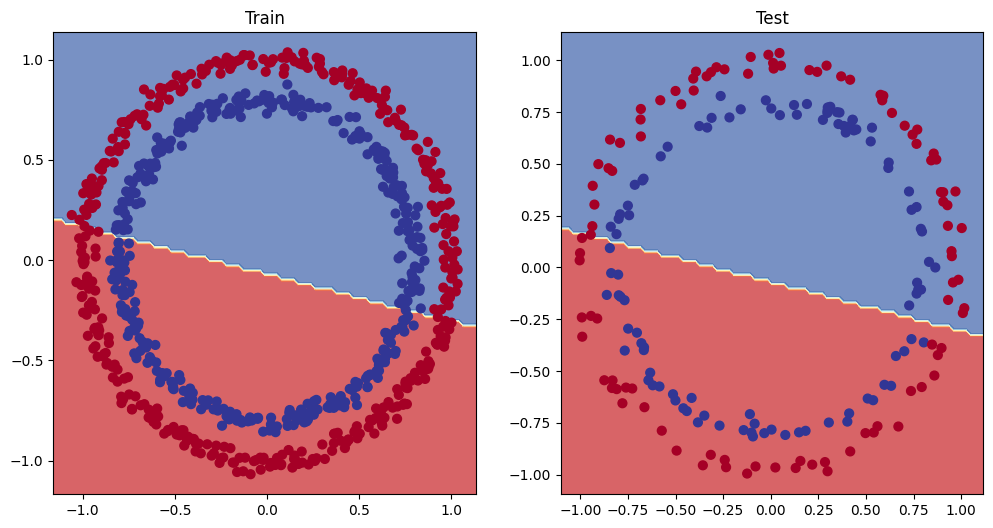

In [32]:
# Plot decision boundary of the model
plt.figure(figsize= (12, 6))
plt.subplot(1, 2, 1)
plt.title("Train")
plot_decision_boundary(model_0, X_train, y_train)
plt.subplot(1, 2, 2)
plt.title("Test")
plot_decision_boundary(model_0, X_test, y_test)

In [33]:
model_0.state_dict()

OrderedDict([('layer1.weight',
              tensor([[-0.1077, -0.1193],
                      [-0.5512,  0.2696],
                      [-0.1432,  0.5115],
                      [-0.1369, -0.2351],
                      [-0.6095, -0.6610],
                      [ 0.0929, -0.0974],
                      [-0.3890, -0.3130],
                      [ 0.4317, -0.2997]])),
             ('layer1.bias',
              tensor([-0.6012, -0.1325, -0.4790, -0.2373,  0.6423,  0.1288,  0.1634, -0.2585])),
             ('layer2.weight',
              tensor([[ 0.2813, -0.0318, -0.0031,  0.1972, -0.1866,  0.0326, -0.0467, -0.1694]])),
             ('layer2.bias', tensor([0.2964]))])

## Improving a model (from a model perspective)
How to do it?
* Add more data.
* Add more layers - give the model more layers to learn about patterns in the data.
* Add more hidden units - go from 5 hidden units to 10 hidden units.
* Fit for longer. Give the model more epochs to learn better.
* Change the activation function.
* Change the learning rate.
* Change the loss function.

These options are all from the model's perspective because they deal directly with the model rather than the data.
And, because these options are all values, we as machine learning engineers and data scientists, we can refer to as **hyperparameters**.

Let's try and improve our model by:
* Adding more hidden units: 5 -> 10
* Increase the number of layers 2-> 3
* Increase the number of epochs:

In [34]:
X_train[:5], y_train[:5]

(tensor([[ 0.6579, -0.4651],
         [ 0.6319, -0.7347],
         [-1.0086, -0.1240],
         [-0.9666, -0.2256],
         [-0.1666,  0.7994]], device='cuda:0'),
 tensor([1., 0., 0., 0., 1.], device='cuda:0'))

In [41]:
class CircleModelV1(nn.Module):
  def __init__(self):
    super().__init__()
    self.layer_1 = nn.Linear(in_features=2,out_features=10)
    self.layer_2 = nn.Linear(in_features=10,out_features=10)
    self.layer_3 = nn.Linear(in_features=10, out_features=1)
  def forward(self, x):
    # Alternate way
    # z = self.layer_1(x)
    # z = self.layer_2(z)
    # z = self.layer_3(z)
    # return z
    return self.layer_3(self.layer_2(self.layer_1(x)))  # This is a faster way tho
model_1 = CircleModelV1().to(device)
model_1, next(model_1.parameters()).device

(CircleModelV1(
   (layer_1): Linear(in_features=2, out_features=10, bias=True)
   (layer_2): Linear(in_features=10, out_features=10, bias=True)
   (layer_3): Linear(in_features=10, out_features=1, bias=True)
 ),
 device(type='cuda', index=0))